Features: (150, 4), Classes: ['setosa' 'versicolor' 'virginica']


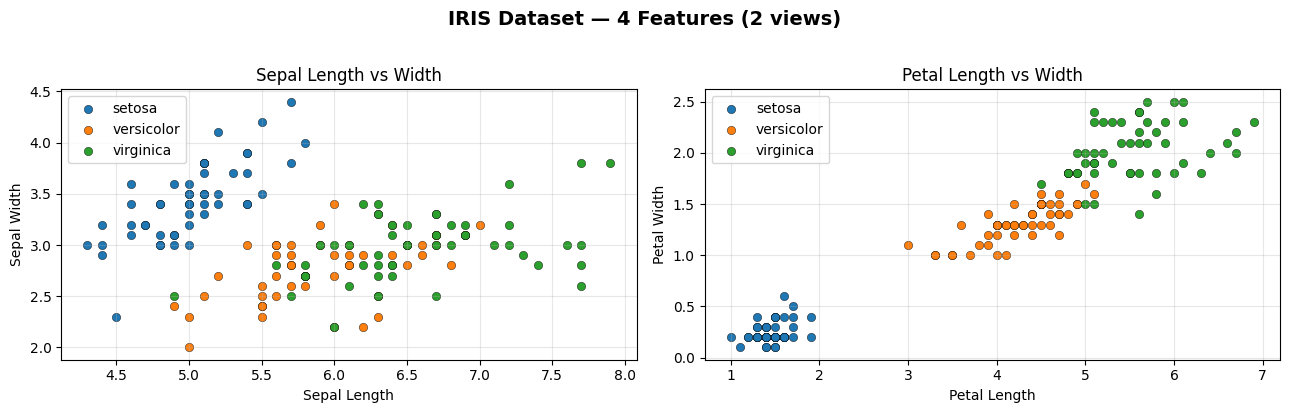

Train Accuracy: 0.9810
Test Accuracy:  0.9778


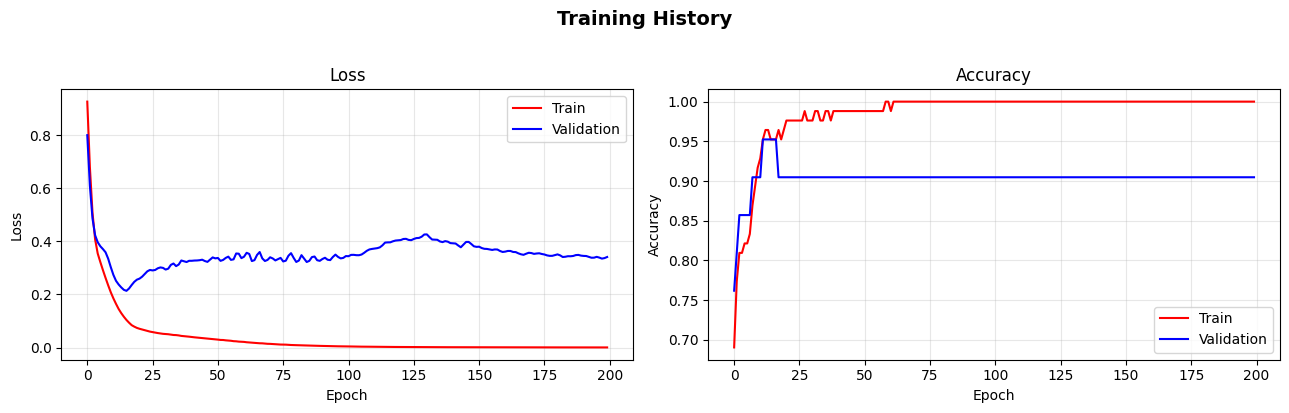

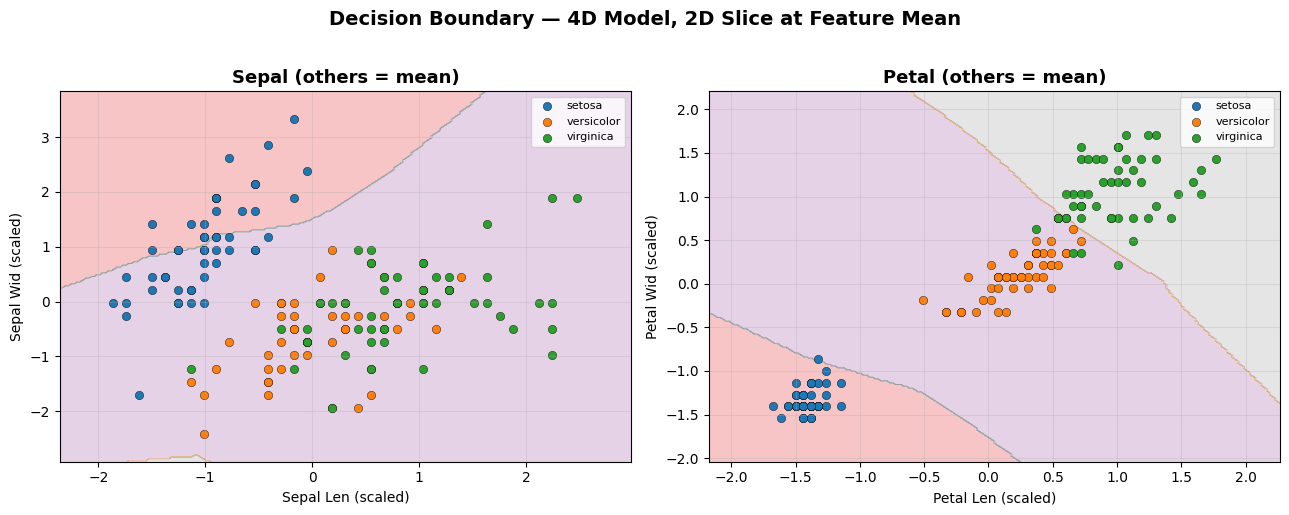

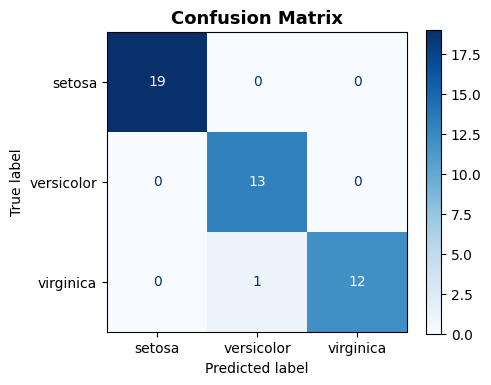

In [1]:
# ==============================
# Week 5 - IRIS 3-Class MLP (Keras)
# Decision Boundary with Mean Imputation
# ==============================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)

# ==============================
# 1. Load & Visualize
# ==============================
iris = load_iris()
X = iris.data          # all 4 features
y = iris.target
names = iris.target_names

print(f"Features: {X.shape}, Classes: {names}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for i, n in enumerate(names):
    ax1.scatter(X[y==i, 0], X[y==i, 1], label=n, edgecolors='k', linewidth=0.3)
ax1.set(title='Sepal Length vs Width', xlabel='Sepal Length', ylabel='Sepal Width')
ax1.legend(); ax1.grid(True, alpha=0.3)

for i, n in enumerate(names):
    ax2.scatter(X[y==i, 2], X[y==i, 3], label=n, edgecolors='k', linewidth=0.3)
ax2.set(title='Petal Length vs Width', xlabel='Petal Length', ylabel='Petal Width')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('IRIS Dataset — 4 Features (2 views)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ==============================
# 2. Preprocessing
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_all = scaler.transform(X)
feat_mean = X_all.mean(axis=0)   # scaled mean ≈ 0

# ==============================
# 3. Build & Train
# ==============================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=200, validation_split=0.2, verbose=0)

# ==============================
# 4. Training History
# ==============================
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
train_acc = accuracy_score(y_train, np.argmax(model.predict(X_train, verbose=0), axis=1))
test_acc = accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['loss'], 'r-', label='Train')
ax1.plot(history.history['val_loss'], 'b-', label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history.history['accuracy'], 'r-', label='Train')
ax2.plot(history.history['val_accuracy'], 'b-', label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
fig.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ==============================
# 5. Decision Boundary (Mean Imputation)
# ==============================
def plot_boundary_4d(ax, model, X_all, y, f1, f2, feat_mean, title, feat_names):
    x_min, x_max = X_all[:, f1].min()-0.5, X_all[:, f1].max()+0.5
    y_min, y_max = X_all[:, f2].min()-0.5, X_all[:, f2].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.tile(feat_mean, (xx.ravel().shape[0], 1))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()
    Z = np.argmax(model.predict(grid, verbose=0), axis=1).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')
    for i, n in enumerate(names):
        ax.scatter(X_all[y==i, f1], X_all[y==i, f2], label=n, edgecolors='k', linewidth=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(feat_names[f1]); ax.set_ylabel(feat_names[f2])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

feat_names = ['Sepal Len (scaled)', 'Sepal Wid (scaled)',
              'Petal Len (scaled)', 'Petal Wid (scaled)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary_4d(ax1, model, X_all, y, 0, 1, feat_mean,
                 'Sepal (others = mean)', feat_names)
plot_boundary_4d(ax2, model, X_all, y, 2, 3, feat_mean,
                 'Petal (others = mean)', feat_names)
fig.suptitle('Decision Boundary — 4D Model, 2D Slice at Feature Mean',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ==============================
# 6. Confusion Matrix
# ==============================
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=names, cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()